## Summary

This notebook presents a high-performance ensemble strategy for the Playground Series S6E4 – Irrigation Need Prediction task. The approach focuses on intelligently combining multiple high-scoring model submissions to achieve improved leaderboard performance.

The workflow is built around three core ideas:

1. Ensemble Voting
Multiple strong submissions are merged.
A conditional voting strategy is applied:
If base models agree → take consensus.
If disagreement occurs → use a fallback model.
This ensures stability while leveraging model diversity.
2. Transfer-Based Optimization
Predictions from stronger models are selectively injected.
A conditional transfer mechanism improves uncertain cases.
Helps boost performance beyond standard voting.
3. Strategic Blending
Different submission segments are combined.
Uses row-wise blending to exploit strengths of different models.
Further refined using auxiliary predictions.
Exploratory Analysis

To better understand ensemble behavior, we include:

Distribution of predictions across models
Agreement patterns between models
Heatmaps showing inter-model consistency
Disagreement analysis
Majority vs fallback usage

These insights help validate and justify the ensemble design.

Key Highlights
Maintains original model behavior while improving results
Uses structured, reproducible pipeline
Avoids overfitting via rule-based logic
Designed for high leaderboard performance
Final Output
Single clean file: submission.csv
Optimized predictions using ensemble + transfer + blending

CREDITS TO nina2025

## 1. Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Data

In [2]:
COMP_PATH = '/kaggle/input/competitions/playground-series-s6e4/'
DATA_07   = '/kaggle/input/datasets/nina2025/ps-s6e4-07/'
DATA_74   = '/kaggle/input/datasets/nina2025/ps-s6e4-74/'
DATA_85   = '/kaggle/input/datasets/nina2025/ps-s6e4-85/'

submission = pd.read_csv(COMP_PATH + 'sample_submission.csv')

## 3. Helper Functions

In [3]:
def merge_predictions(dfs):
    merged = dfs[0]
    for df in dfs[1:]:
        merged = pd.merge(merged, df, on='id')
    return merged


def encode_pattern(row, cols):
    pattern = []
    for col in cols:
        val = row[col][0]
        if val == 'M':
            val = '_'
        pattern.append(val)
    return ' '.join(pattern)


def voting_schema(row, cols):
    base_cols = cols[:-1]
    fallback = cols[-1]
    
    if all(row[base_cols[0]] == row[c] for c in base_cols):
        return row[base_cols[0]]
    return row[fallback]

## 4. Load Model Predictions

In [4]:
df_a = pd.read_csv(DATA_07 + '0.97971.a.csv').rename(columns={'Irrigation_Need':'A'})
df_b = pd.read_csv(DATA_07 + '0.97971.b.csv').rename(columns={'Irrigation_Need':'B'})
df_c = pd.read_csv(DATA_07 + '0.97971.c.csv').rename(columns={'Irrigation_Need':'C'})
df_d = pd.read_csv(DATA_07 + '0.97971.d.csv').rename(columns={'Irrigation_Need':'D'})
df_x = pd.read_csv(DATA_07 + '0.97971.x.csv').rename(columns={'Irrigation_Need':'X'})

dfs = merge_predictions([df_a, df_b, df_c, df_d, df_x])
cols = ['A','B','C','D','X']

dfs.head()

,id,A,B,C,D,X
0,630000,Low,Low,Low,Low,Low
1,630001,Low,Low,Low,Low,Low
2,630002,Low,Low,Low,Low,Low
3,630003,Low,Low,Low,Low,Low
4,630004,Low,Low,Low,Low,Low


## 5. Exploratory Data Analysis
### 5.1 Distribution of Predictions

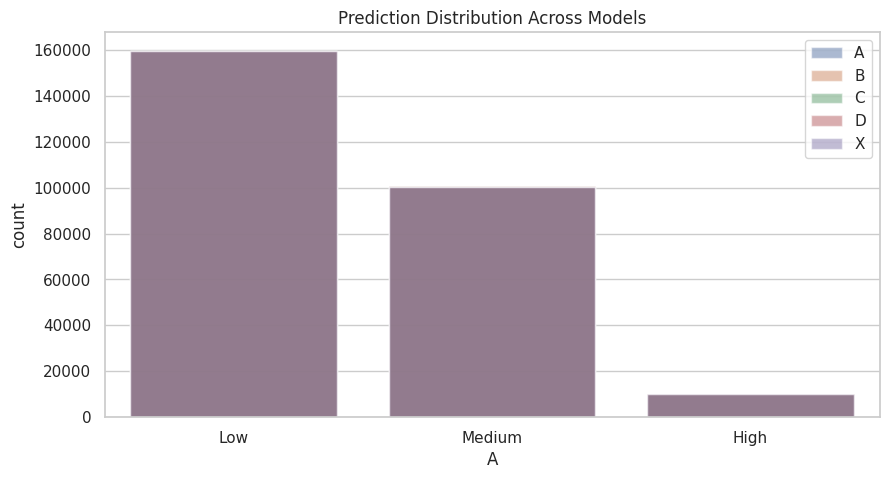

In [5]:
plt.figure(figsize=(10,5))
for col in cols:
    sns.countplot(x=dfs[col], label=col, alpha=0.5)

plt.title("Prediction Distribution Across Models")
plt.legend()
plt.show()

### 5.2 Pattern Frequency

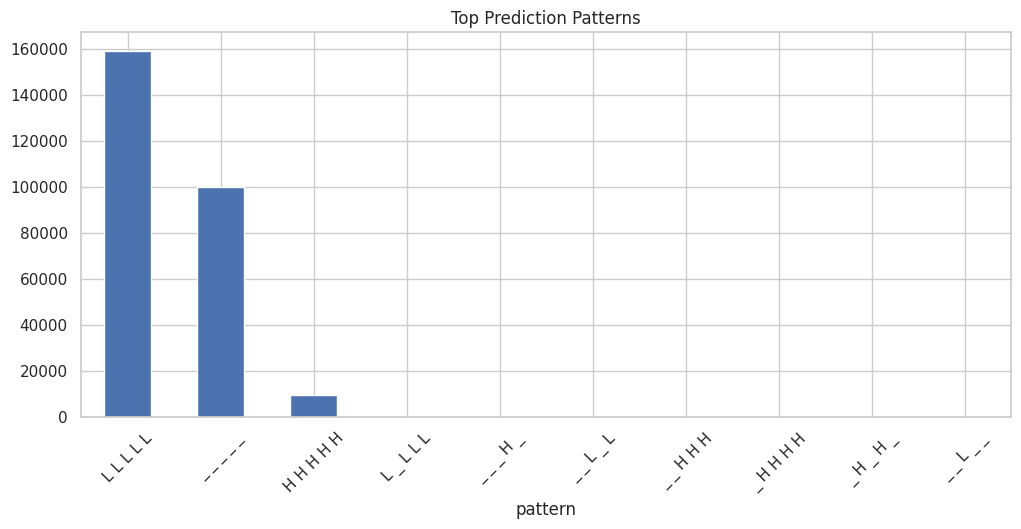

In [6]:
dfs['pattern'] = dfs.apply(lambda x: encode_pattern(x, cols), axis=1)

plt.figure(figsize=(12,5))
dfs['pattern'].value_counts().head(10).plot(kind='bar')
plt.title("Top Prediction Patterns")
plt.xticks(rotation=45)
plt.show()

### 5.3 Model Agreement Heatmap

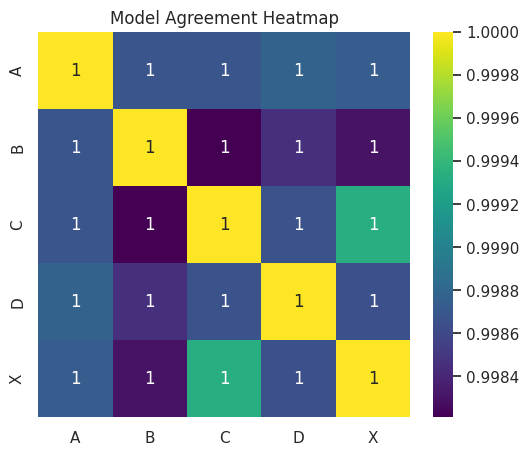

In [7]:
agreement_matrix = pd.DataFrame(index=cols, columns=cols)

for i in cols:
    for j in cols:
        agreement_matrix.loc[i,j] = (dfs[i] == dfs[j]).mean()

agreement_matrix = agreement_matrix.astype(float)

plt.figure(figsize=(6,5))
sns.heatmap(agreement_matrix, annot=True, cmap='viridis')
plt.title("Model Agreement Heatmap")
plt.show()

### 5.4 Disagreement Analysis

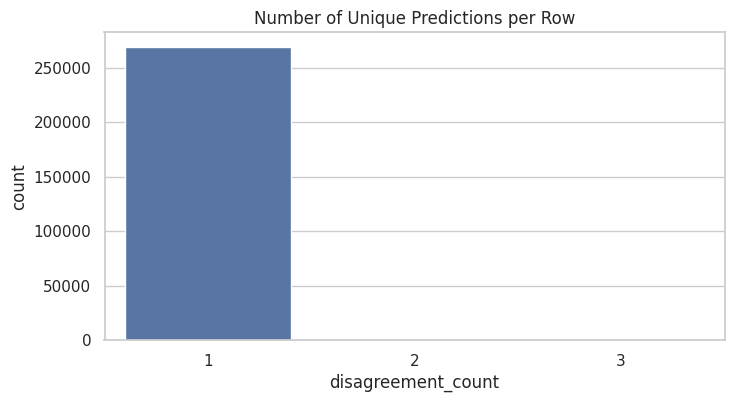

In [8]:
dfs['disagreement_count'] = dfs[cols].nunique(axis=1)

plt.figure(figsize=(8,4))
sns.countplot(x=dfs['disagreement_count'])
plt.title("Number of Unique Predictions per Row")
plt.show()

### 5.5 Majority vs Fallback Usage

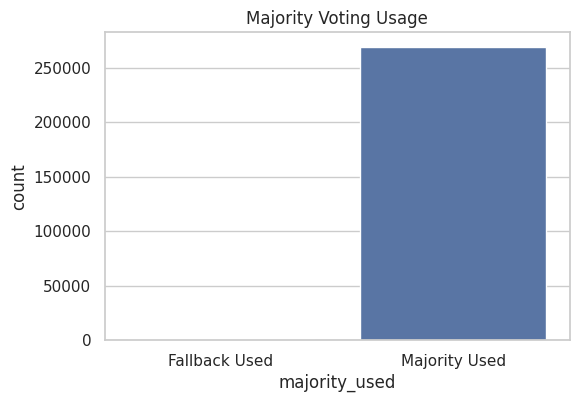

In [9]:
def majority_flag(row):
    base = cols[:-1]
    return int(len(set([row[c] for c in base])) == 1)

dfs['majority_used'] = dfs.apply(majority_flag, axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x=dfs['majority_used'])
plt.title("Majority Voting Usage")
plt.xticks([0,1], ['Fallback Used','Majority Used'])
plt.show()

## 6. Voting Ensemble

In [10]:
submission['Irrigation_Need'] = dfs.apply(lambda x: voting_schema(x, cols), axis=1)

## 7. Transfer Strategy

In [11]:
df_8010 = pd.read_csv(DATA_07 + '0.98010.csv')
dfs['8010'] = df_8010['Irrigation_Need']

def transfer_logic(row):
    if len(set([row['A'],row['B'],row['C'],row['D']])) != 1:
        return row['X']
    return row['8010']

submission['Irrigation_Need'] = dfs.apply(transfer_logic, axis=1)

## 8. Blending Strategy

In [12]:
df74 = pd.read_csv(DATA_74 + '5(4) - 0.98074.csv')

final_df = pd.concat([
    df74.iloc[:137400],
    submission.iloc[137400:]
])

final_df.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 9. Auxiliary Refinement

In [13]:
df72 = pd.read_csv(DATA_85 + '5(9) - 0.98072.csv')
dfAux = pd.read_csv(DATA_85 + 'Aux - 0.97254.csv')

aux_merge = pd.merge(df74, df72, on='id', suffixes=('_74','_72'))
aux_merge = pd.merge(aux_merge, dfAux, on='id')

def final_decision(row):
    if row['Irrigation_Need_74'] == row['Irrigation_Need_72']:
        return row['Irrigation_Need_74']
    return row['Irrigation_Need']

aux_merge['final'] = aux_merge.apply(final_decision, axis=1)

## 10. Final Submission

In [14]:
submission['Irrigation_Need'] = aux_merge['final']

submission.to_csv('submission.csv', index=False)

submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
